<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_72_Linear_Regression_Assumptions/Lecture_72_Linear_Regression_Assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset from the specified CSV file
df = pd.read_csv('/content/data (1).csv')

In [3]:
# Display the first 5 rows of the dataframe
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
# Separate the features (X) and the target variable (y)
X = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

In [5]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [6]:
# Import and train the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Make predictions on the test set and calculate the residuals
y_pred = model.predict(X_test)
residual = y_test - y_pred

# 1.Linear Relationship

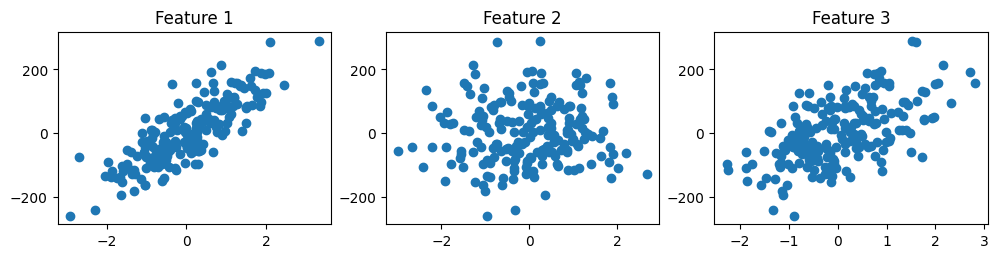

In [9]:
# Create subplots to visualize the relationship between each feature and the target
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

# Scatter plot for feature 1 vs target
ax1.scatter(df['feature1'], df['target'])
ax1.set_title('Feature 1')

# Scatter plot for feature 2 vs target
ax2.scatter(df['feature2'], df['target'])
ax2.set_title('Feature 2')

# Scatter plot for feature 3 vs target
ax3.scatter(df['feature3'], df['target'])
ax3.set_title('Feature 3')

# Display the plots
# plt.tight_layout()
plt.show()

# 2. Multicollinearity

In [10]:
# Calculate the Variance Inflation Factor (VIF) to check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [11]:
# Display the VIF values in a DataFrame
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

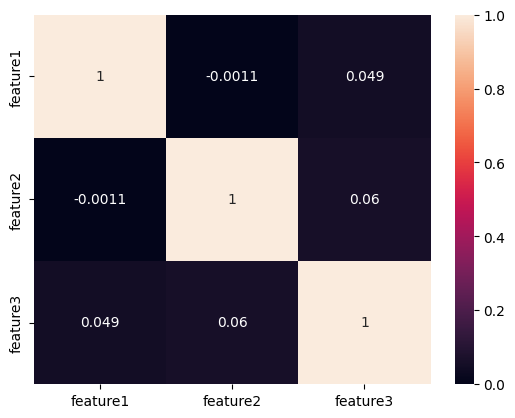

In [12]:
# Create a heatmap of the correlation matrix to visualize multicollinearity
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)